# Financial Market Dashboard
## Simplified Interactive Analysis

## 1. Initial Setup

In [1]:
# Install required packages
!pip install pandas yfinance fredapi matplotlib

# Import libraries
import pandas as pd
import yfinance as yf
from fredapi import Fred
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

# Initialize FRED API
fred = Fred(api_key='ffa1c3fabd429889449e01d7e3cd1c5f')  # Replace with your FRED key

%matplotlib inline

Defaulting to user installation because normal site-packages is not writeable


/Users/h4nty/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## 2. Data Selection

Select which data series you want to analyze by uncommenting lines below:

In [2]:
# Available data series (uncomment what you want)
selected_data = {
    # Inflation
    'PCE': 'PCE',
    'Core PCE': 'PCEPILFE',
    'CPI': 'CPIAUCSL',
    
    # Yields
    '2Y Yield': 'DGS2',
    '10Y Yield': 'DGS10',
    '30Y Yield': 'DGS30',
    
    # Liquidity
    'Fed Balance Sheet': 'WALCL',
    'M2 Money Supply': 'M2SL',
    
    # Market
    'S&P 500': '^GSPC',
    'VIX': '^VIX',
    'Dollar Index': 'DX-Y.NYB'
}

# Edit this dictionary to select your series
user_selection = {
    'PCE': 'PCE',
    '10Y Yield': 'DGS10',
    'S&P 500': '^GSPC'
}

## 3. Inflation Analysis

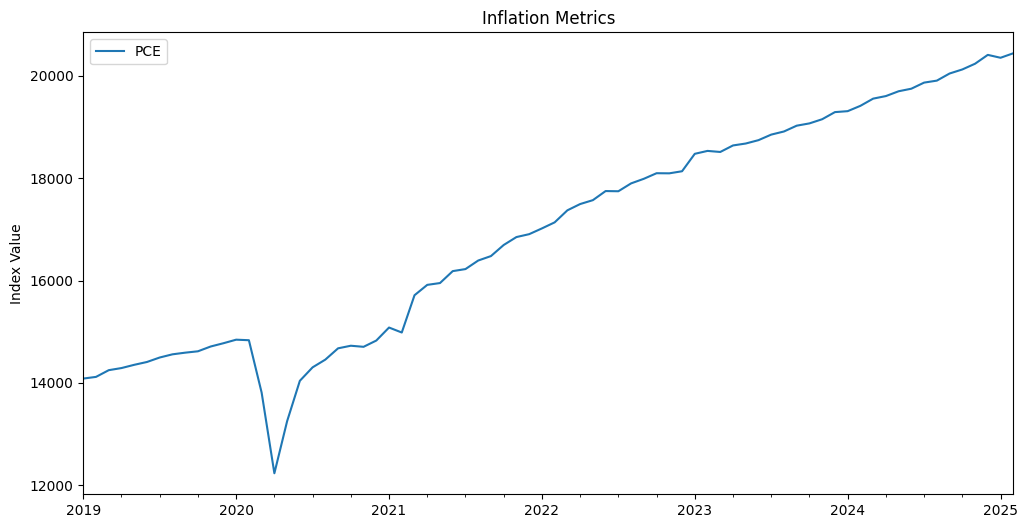

In [3]:
# Set time period
start_date = input("Enter start date (YYYY-MM-DD): ") or '2019-01-01'
end_date = input("Enter end date (YYYY-MM-DD): ") or datetime.now().strftime('%Y-%m-%d')

# Load inflation data
inflation_data = {}
for name, code in user_selection.items():
    if code in ['PCE', 'PCEPILFE', 'CPIAUCSL']:
        try:
            inflation_data[name] = fred.get_series(code, start_date, end_date)
        except:
            print(f"Could not load {name}")

# Plot
if inflation_data:
    pd.DataFrame(inflation_data).plot(figsize=(12,6))
    plt.title("Inflation Metrics")
    plt.ylabel("Index Value")
    plt.show()
else:
    print("No inflation data selected")

## 4. Money Supply Analysis

In [4]:
# Load liquidity data
liquidity_data = {}
for name, code in user_selection.items():
    if code in ['WALCL', 'M2SL']:
        try:
            liquidity_data[name] = fred.get_series(code, start_date, end_date)
        except:
            print(f"Could not load {name}")

# Plot
if liquidity_data:
    pd.DataFrame(liquidity_data).plot(figsize=(12,6))
    plt.title("Money Supply Metrics")
    plt.ylabel("Billions of Dollars")
    plt.show()
else:
    print("No liquidity data selected")

No liquidity data selected


## 5. Yield Curve Analysis

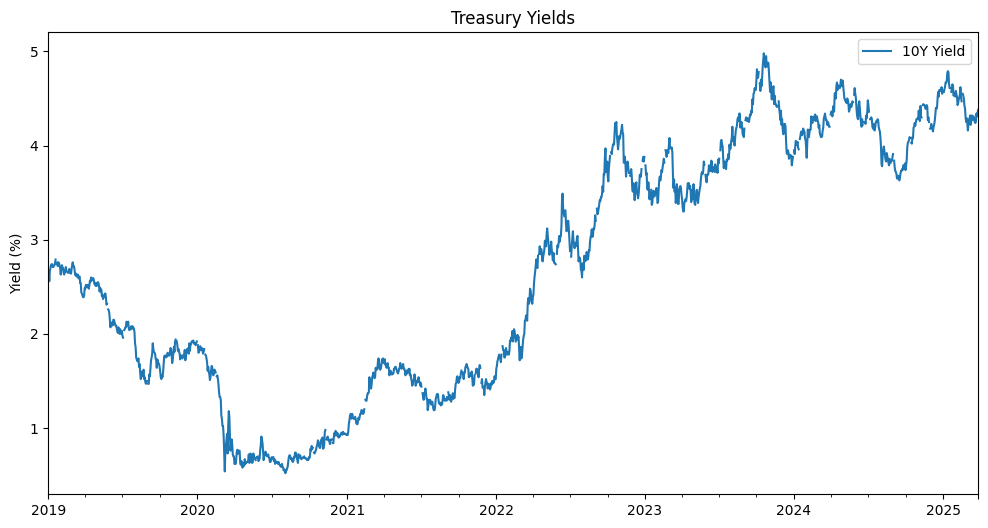

In [5]:
# Load yield data
yield_data = {}
for name, code in user_selection.items():
    if code in ['DGS2', 'DGS10', 'DGS30']:
        try:
            yield_data[name] = fred.get_series(code, start_date, end_date)
        except:
            print(f"Could not load {name}")

# Plot
if yield_data:
    pd.DataFrame(yield_data).plot(figsize=(12,6))
    plt.title("Treasury Yields")
    plt.ylabel("Yield (%)")
    plt.show()
else:
    print("No yield data selected")

## 6. Market Data Analysis

In [6]:
# Load market data
market_data = {}
for name, code in user_selection.items():
    if code in ['^GSPC', '^VIX', 'DX-Y.NYB']:
        try:
            market_data[name] = yf.download(code, start=start_date, end=end_date)['Close']
        except:
            print(f"Could not load {name}")

# Plot
if market_data:
    pd.DataFrame(market_data).plot(figsize=(12,6))
    plt.title("Market Indicators")
    plt.ylabel("Value")
    plt.show()
else:
    print("No market data selected")

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


ValueError: If using all scalar values, you must pass an index